<a href="https://colab.research.google.com/github/JakeOh/202511_BD53/blob/main/lab_ml/ml17_ann_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion MNIST 데이터셋 이미지 분류

# Imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

import tensorflow as tf
import keras

In [2]:
tf.__version__

'2.19.0'

In [3]:
keras.__version__

'3.13.2'

In [4]:
print(tf.config.list_physical_devices())  # CPU/GPU/TPU 사용 여부 확인

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [5]:
print(keras.config.backend())  # keras 라이브러리에서 텐서 연산을 할 때 필요한 라이브러리.

tensorflow


Keras 라이브러리는 텐서 연산을 직접 수행하지 않음. 대신에 텐서 연산을 수행하는 다른 딥러닝 라이브러리를 백엔드(backend)로 활용함.

*   Keras에서 사용하는 백엔드 종류
    *   TensorFlow - 구글에서 만든 텐서 연산 라이브러리.
    *   PyTorch - 메타에서 만든 딥러닝 라이브러리 -> 리눅스 재단으로 이전, 오픈소스로 공개됨.
*   Keras
    *   여러가지 백엔드를 사용해서 신경망을 쉽게 만들고 훈련할 수 있도록 만든 고급 라이브러리.
    *   2.3.1 버전 이후부터는 TensorFlow만 단일 백엔드로 사용하도록 기능 변경.
    *   3.0 버전부터 다시 멀티 백엔드 정책으로 바뀜.

# Fashion MNIST 데이터 셋

10개 클래스(예: 바지, 셔츠, 구두, ...)의 패션 아이템들의 28x28 크기의 흑백 이미지. 60,000개 훈련 셋/레이블, 10,000개 테스트 셋/레이블.

In [6]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
x_train.shape  #> (n_samples, width, height)

(60000, 28, 28)

In [8]:
y_train.shape  #> (n_samples)

(60000,)

In [9]:
x_test.shape

(10000, 28, 28)

In [10]:
y_test.shape

(10000,)

In [12]:
# 훈련 레이블의 중복되지 않는 값들 개수
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [13]:
# 테스트 레이블의 중복되지 않는 값들
np.unique(y_test, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))

훈련 셋과 테스트 셋 모두 각 클래스의 샘플들이 같은 개수로 수집되어 있음.

In [14]:
x_train[0]  #> 0(black) ~ 255(white) scale의 28x28 크기의 흑백 이미지

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

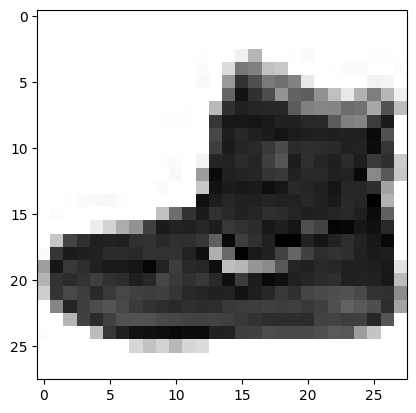

In [18]:
plt.imshow(x_train[0], cmap=plt.cm.binary)
plt.show()

In [19]:
def plot_fashion_mnist(arr, ncols=10):
    # arr: (n_samples, width, height) shape의 3차원 배열
    # ncols: subplot axis의 컬럼 개수.
    n = len(arr)  # 출력할 이미지 개수
    nrows = int(np.ceil(n / ncols))  # subplot axis의 행 개수
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols, nrows))
    for i in range(nrows):
        for j in range(ncols):
            idx = i * ncols + j  # 배열 arr에서 선택할 이미지의 인덱스
            if nrows == 1 or ncols == 1:  # axes는 1차원 배열
                if idx < n:
                    axes[idx].imshow(arr[idx], cmap=plt.cm.binary)
                axes[idx].axis('off')
            else:  # axes는 2차원 배열
                if idx < n:
                    axes[i, j].imshow(arr[idx], cmap=plt.cm.binary)
                axes[i, j].axis('off')
    plt.show()

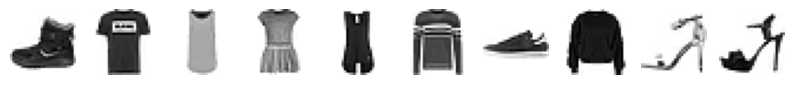

In [20]:
plot_fashion_mnist(x_train[:10])

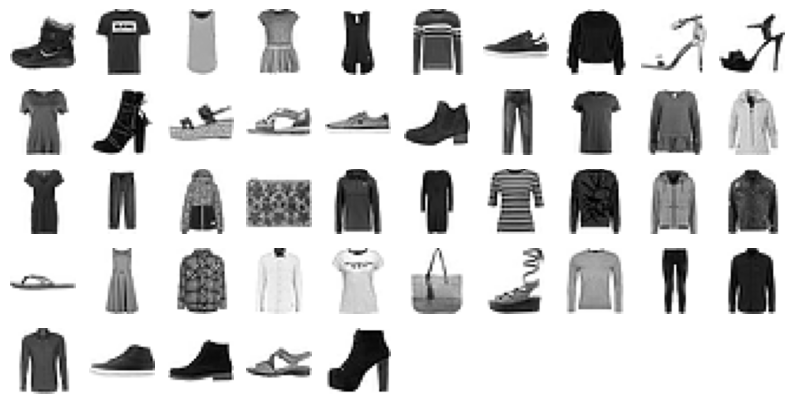

In [22]:
plot_fashion_mnist(x_train[:45])

# 훈련 셋 스케일링, 훈련/검증 분리

In [23]:
# 훈련 셋의 스케일을 0 ~ 1 사이의 값으로 변경 -> SGDClassifier의 성능 향상을 위해서
x_train_scaled = x_train / 255

In [24]:
# 훈련 셋과 훈련 레이블을 훈련/검증으로 분리
train_input, val_input, train_target, val_target = train_test_split(x_train_scaled, y_train,
                                                                    test_size=0.2,
                                                                    random_state=42,
                                                                    stratify=y_train)

In [25]:
train_input.shape

(48000, 28, 28)

In [26]:
train_target.shape

(48000,)

# SGD Classifier

In [27]:
sgd = SGDClassifier(loss='log_loss', random_state=42, n_jobs=-1)  # 모델 생성

In [28]:
# 모델 훈련 - (주의) 훈련 셋은 (n_samples, n_features) shape의 2차원 배열이어야 함!
sgd.fit(X=train_input.reshape((48_000, -1)), y=train_target)

SGDClassifier(loss='log_loss', n_jobs=-1, random_state=42)

In [30]:
sgd.coef_.shape

(10, 784)

In [31]:
sgd.intercept_.shape

(10,)

In [32]:
# 각 클래스가 될 확률
predict_probs = sgd.predict_proba(X=train_input.reshape((48_000, -1)))

In [33]:
predict_probs[:2]

array([[1.20888251e-02, 1.05549631e-05, 2.30094285e-01, 3.41231387e-03,
        4.86284532e-02, 3.96063160e-10, 6.91742929e-01, 1.54454383e-17,
        1.40226378e-02, 1.05805064e-16],
       [7.53889861e-01, 1.20438290e-04, 4.89841116e-05, 2.88644150e-04,
        7.52168267e-02, 4.15812599e-17, 1.69806662e-01, 2.22627871e-15,
        6.28584469e-04, 3.41774283e-15]])

In [34]:
predicts = sgd.predict(X=train_input.reshape((48_000, -1)))

In [35]:
predicts[:2]

array([6, 0], dtype=uint8)

In [36]:
accuracy_score(y_true=train_target, y_pred=predicts)  # 훈련 셋 정확도

0.8518125

In [37]:
# 검증 셋 평가
val_input_2d = val_input.reshape((12_000, -1))  # 3d 배열 -> 2d 배열
val_predicts = sgd.predict(X=val_input_2d)  # 검증 셋 예측값
accuracy_score(y_true=val_target, y_pred=val_predicts)  # 검증 셋 정확도

0.8468333333333333

# 입력층과 출력층만 갖는 신경망

In [38]:
train_input_2d = train_input.reshape((48_000, -1))
train_input_2d.shape

(48000, 784)

In [39]:
# 입력층(input layer)
inputs = keras.Input(shape=(784,))

In [40]:
# 출력층(output layer)
dense = keras.layers.Dense(units=10, activation='softmax')

In [41]:
# 완전연결 신경망
model = keras.Sequential(layers=[inputs, dense])

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# 신경망 모델 컴파일
model.compile(optimizer=keras.optimizers.SGD(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [44]:
# 신경망 모델 훈련
model.fit(x=train_input_2d, y=train_target, batch_size=64, epochs=10)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.0308 - sparse_categorical_accuracy: 0.6762
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7081 - sparse_categorical_accuracy: 0.7714
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6366 - sparse_categorical_accuracy: 0.7949
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5973 - sparse_categorical_accuracy: 0.8055
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5717 - sparse_categorical_accuracy: 0.8137
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5533 - sparse_categorical_accuracy: 0.8180
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5392 - sparse_categorical_accuracy: 0.8223
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5278 - sparse_categorical_accuracy: 0.8263
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5184 - sparse_categorical_accuracy: 0.8290
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - 

In [46]:
# 훈련된 신경망 모델이 찾은 모델 파라미터들(가중치, weights)
model.weights

[<Variable path=sequential/dense/kernel, shape=(784, 10), dtype=float32, value=[[-0.03638427 -0.0732877   0.06617396 ... -0.04060814 -0.03083796
    0.02955327]
  [-0.08035462  0.02782443  0.04650563 ...  0.02641317 -0.06100487
    0.02546145]
  [-0.01092758  0.04581895  0.01788523 ... -0.03060454  0.03457008
    0.02332235]
  ...
  [-0.04004796  0.07913639  0.03296407 ...  0.06866192 -0.07814079
    0.00991774]
  [-0.08592203 -0.0606335   0.01055795 ... -0.08312781  0.03665807
    0.05673005]
  [ 0.05752583  0.08205271  0.0483273  ... -0.03584904 -0.03997028
   -0.05938311]]>,
 <Variable path=sequential/dense/bias, shape=(10,), dtype=float32, value=[ 0.1020273  -0.0981015  -0.10092483  0.02109792 -0.47843254  1.1422762
   0.23010059 -0.07909268 -0.24983072 -0.4891222 ]>]

In [47]:
predicts = model.predict(x=train_input_2d)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [48]:
predicts.shape  #> (48_000, 10) = (n_samples, n_classes)

(48000, 10)

In [49]:
predicts[:2]

array([[9.1446647e-03, 5.2438799e-04, 2.0311712e-01, 2.2016905e-02,
        4.8904706e-02, 5.4288957e-05, 7.1058887e-01, 1.0981229e-06,
        5.6380755e-03, 9.7839538e-06],
       [5.2978855e-01, 3.6844451e-04, 1.4348270e-03, 1.0135731e-02,
        1.2956618e-02, 1.5837429e-07, 4.4494951e-01, 1.9446662e-07,
        3.6337198e-04, 2.5284269e-06]], dtype=float32)

In [50]:
# 훈련 셋의 예측 레이블 계산 - 10개의 확률들 중 최댓값의 인덱스.
train_pred_labels = predicts.argmax(axis=1)

In [51]:
train_pred_labels[:2]

array([6, 0])

In [52]:
accuracy_score(y_true=train_target, y_pred=train_pred_labels)  # 훈련 셋 정확도

0.8324583333333333

In [53]:
model.evaluate(x=train_input_2d, y=train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5055 - sparse_categorical_accuracy: 0.8325


[0.5054816603660583, 0.8324583172798157]

In [54]:
# 검증 셋 정확도
model.evaluate(x=val_input_2d, y=val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4954 - sparse_categorical_accuracy: 0.8367


[0.4953712224960327, 0.8366666436195374]